## Bibliotecas

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, recall_score, f1_score, confusion_matrix, classification_report,accuracy_score, precision_score


# Baixando Dados de Treino e Teste

In [2]:
dados_treino = pd.read_csv('train.csv', encoding="utf-8-sig") # Lê o arquivo CSV de treinamento 
dados_teste = pd.read_csv('test.csv', encoding="utf-8-sig") # Lê o arquivo CSV de teste

# Para visualização de todas as colunas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
dados_treino.head()

,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,265519,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,-0.113729,0.510277,0.061258,-0.066555,1.328702,0.352514,-0.765670,0.141938,-0.451365,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32,0
1,180306,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,-0.254903,0.325560,-0.405327,0.721068,-0.148445,-0.754029,-0.270842,-0.695698,-0.274411,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99,0
2,42665,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,-0.386845,1.820161,0.747777,0.122746,-1.723285,1.123344,-0.724616,0.147255,0.004631,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,0
3,198724,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,0.093136,-0.722450,-0.468757,-0.195288,-0.638683,-0.065888,0.072781,0.768237,0.257424,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10,0
4,82326,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,-0.251076,-0.054708,-0.782698,0.134659,-0.483007,-2.096099,-0.399525,1.597589,-0.082746,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10,0


# Pré-Análise dos dados

In [3]:
fraude = (dados_treino["Class"] == 1).sum() # Conta a quantidade de transações fraudulentas
normal = (dados_treino["Class"] == 0).sum() # Conta a quantidade de transações normais
print(f"Quantidade de transações fraudulentas: {fraude}")
print(f"Quantidade de transações normais: {normal}")

Quantidade de transações fraudulentas: 394
Quantidade de transações normais: 227451


In [4]:
print("Quantidade de dados nulos em dados_treino:", dados_treino.isnull().sum().sum()) # ve a a quantidade de dados nulos no conjunto de treinamento
print("Quantidade de dados nulos em dados_teste:", dados_teste.isnull().sum().sum()) # ve a quantidade de dados nulos no conjunto de teste

print("tipos de dados em dados_treino:")
print(dados_treino.dtypes) # ve os tipos de dados em dados_treino

Quantidade de dados nulos em dados_treino: 0
Quantidade de dados nulos em dados_teste: 0
tipos de dados em dados_treino:
id          int64
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


## Distribuição dos dados de cada Feature referentes as 2 classes

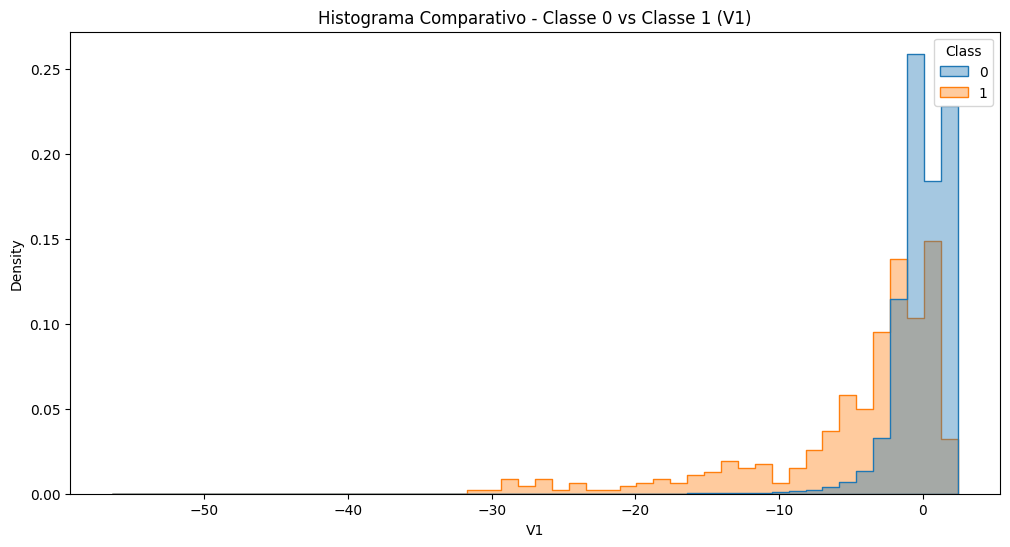

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.histplot(
    data=dados_treino,
    x="V1",              # escolha a variável aqui
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.4
)

plt.title("Histograma Comparativo - Classe 0 vs Classe 1 (V1)")
plt.show()


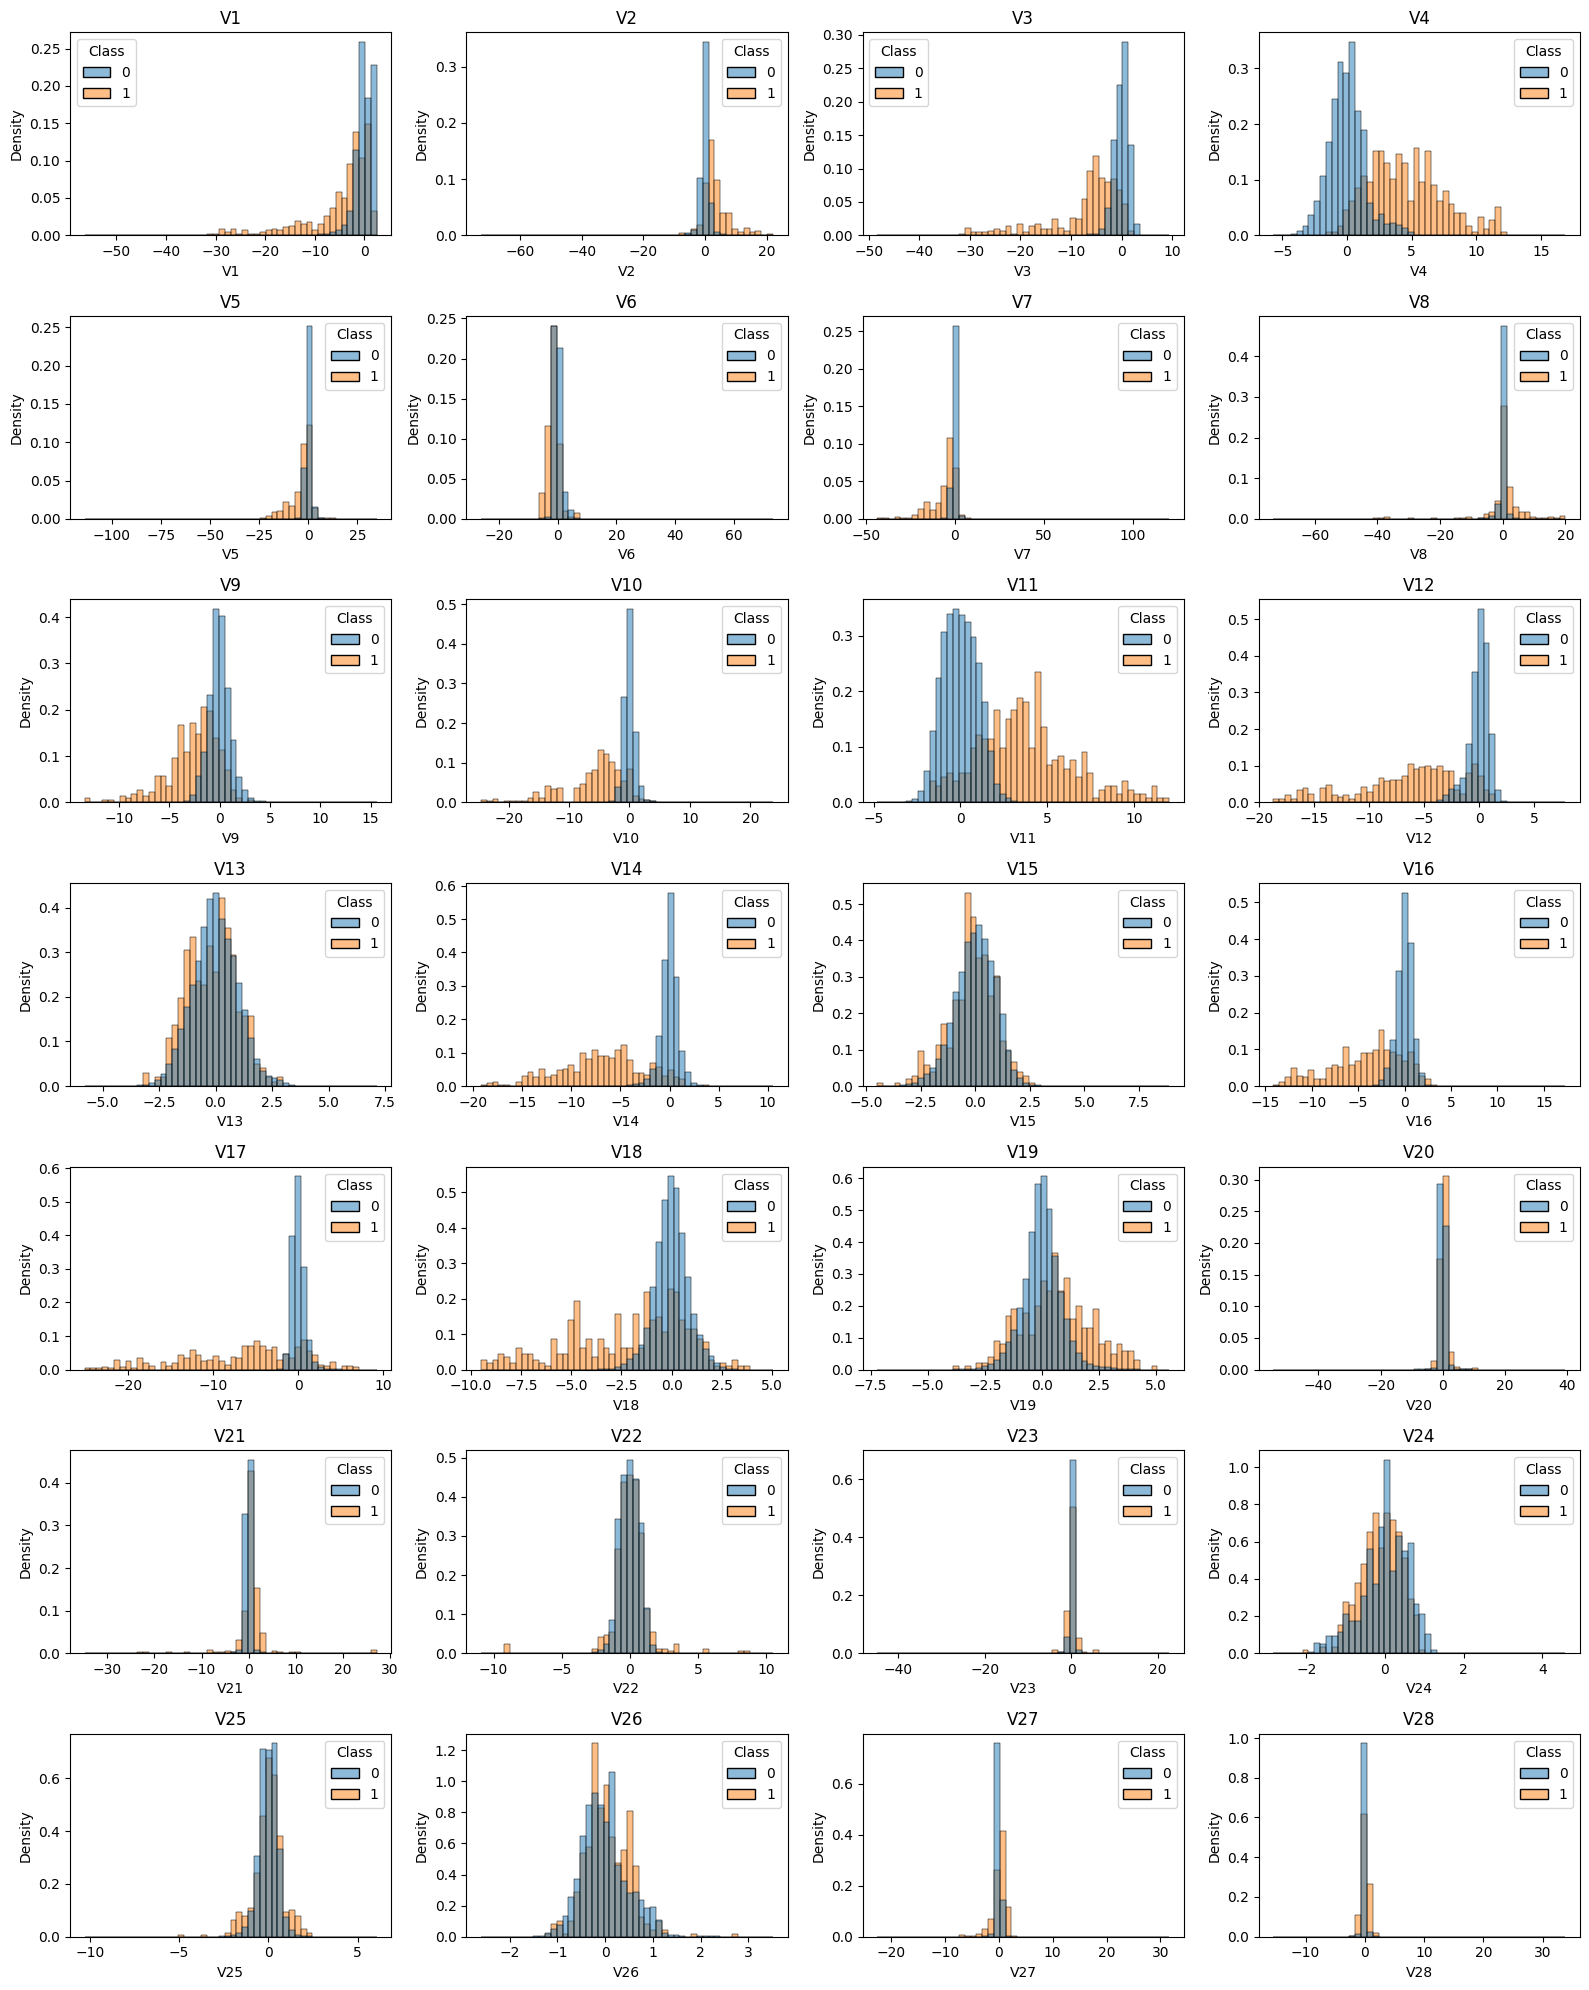

In [6]:
fig, axes = plt.subplots(7, 4, figsize=(16, 20)) 
axes = axes.flatten()
v_cols = [f"V{i}" for i in range(1, 29)]

for ax, col in zip(axes, v_cols):
    sns.histplot(
        data=dados_treino,
        x=col,
        hue="Class",
        bins=50,
        stat="density",
        common_norm=False,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()


## Análise da matriz de correlação

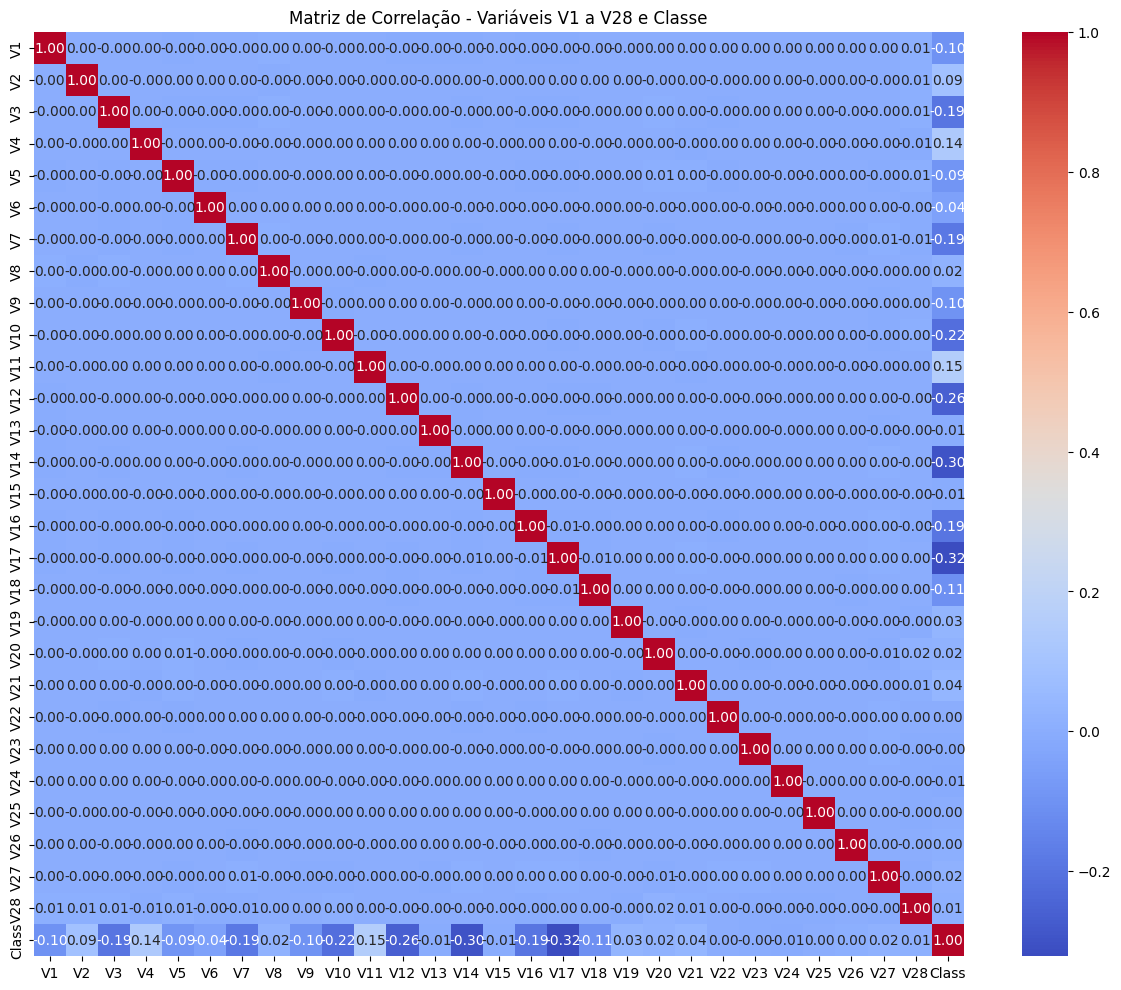

In [ ]:
v_cols = [f"V{i}" for i in range(1, 29)] # Cria uma lista com os nomes das colunas V1 a V28
corre_matriz = dados_treino[v_cols + ["Class"]].corr() # Calcula a matriz de correlação para as colunas V1 a V28 e a coluna "Class"
plt.figure(figsize=(15, 12))
sns.heatmap(corre_matriz, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação - Variáveis V1 a V28 e Classe")
plt.show()

## Separação dos dados de Treino e Teste 

In [3]:
X = dados_treino.drop(columns=["Class", "id"]) # removendo as colunas de id e classe, pois a classe é o target e a coluna id não tem utilidade para o modelo
y = dados_treino["Class"] # pegando a coluna de classe como target

X_teste_final = dados_teste.drop(columns=["id"]) # variavel de teste final, removendo a coluna id

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2, # 20% para validação
    stratify=y, # estratificando para manter a proporção de classes
    random_state=42 # para reprodutibilidade
)

## Modelo Utilizado: LogisticRegression

 **modelo de classificação supervisionada que estima a probabilidade de uma amostra pertencer a uma classe, usando uma função logística para gerar saídas entre 0 e 1.**

In [4]:
model_LR= LogisticRegression(
    class_weight="balanced",  # lida com desbalanceamento
    max_iter=2000 # aumenta o número de iterações para  convergência
)

model_LR.fit(X_train, y_train) #treinando o modelo com 80% dos dados para treino

c:\Users\julia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


# Importâncias de cada feature para o treinamento

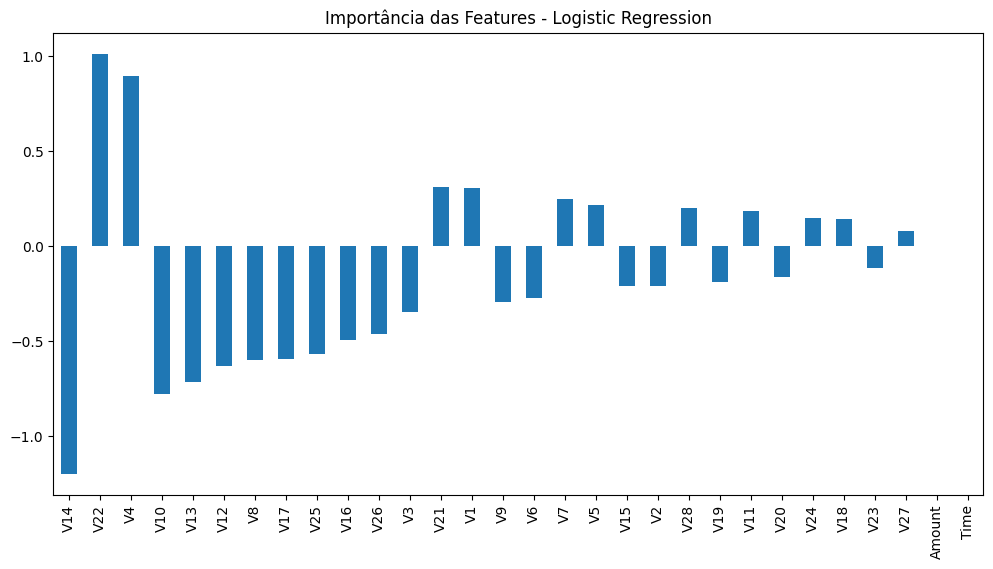

In [ ]:
features_usadas = dados_treino.drop(columns=["id", "Class"]).columns

coef = model_LR.coef_[0] # coeficientes do modelo para cada feature

importancia = pd.Series(
    coef,
    index=features_usadas
).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(12,6))
importancia.plot(kind="bar")
plt.title("Importância das Features - Logistic Regression")
plt.show()


# Cálculo da Melhor trashold

In [5]:
# Probabilidade da classe positiva
y_val_proba = model_LR.predict_proba(X_val)[:, 1]
precisions_lr, recalls_lr, thresholds = precision_recall_curve(y_val, y_val_proba)
# Escolher threshold que maximiza F1
f1_scores = 2 * (precisions_lr * recalls_lr) / (precisions_lr + recalls_lr + 1e-8)  # Adicionando um pequeno valor para evitar divisão por zero
best_threshold = thresholds[f1_scores.argmax()]
print("Melhor threshold:", best_threshold)

Melhor threshold: 0.9999966005035689


In [6]:
# Fazendo as previsões no conjunto de teste
predictions = model_LR.predict(X_teste_final)

print(f"Total de previsões: {len(predictions)}")
print(f"Previsões de fraude: {sum(predictions)}")
print(f"Previsões de transações normais: {len(predictions) - sum(predictions)}")


# Previsões discretas
y_val_pred = (y_val_proba >= best_threshold).astype(int)

print("Threshold usado:", best_threshold)

# ROC-AUC
roc_auc = roc_auc_score(y_val, y_val_proba)
print("ROC-AUC:", roc_auc)

# Accuracy
accuracy = accuracy_score(y_val, y_val_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_val, y_val_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_val, y_val_pred)
print("Recall:", recall)

# F1-score
f1 = f1_score(y_val, y_val_pred)
print("F1-score:", f1)

# Relatório completo
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))


Total de previsões: 56962
Previsões de fraude: 1575
Previsões de transações normais: 55387
Threshold usado: 0.9999966005035689
ROC-AUC: 0.9723576749375994
Accuracy: 0.9992758234764862
Precision: 0.8484848484848485
Recall: 0.7088607594936709
F1-score: 0.7724137931034483

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45490
           1       0.85      0.71      0.77        79

    accuracy                           1.00     45569
   macro avg       0.92      0.85      0.89     45569
weighted avg       1.00      1.00      1.00     45569



# Matriz de Confusão Utilizando e Curva  Precision-recal a melhor trashhord

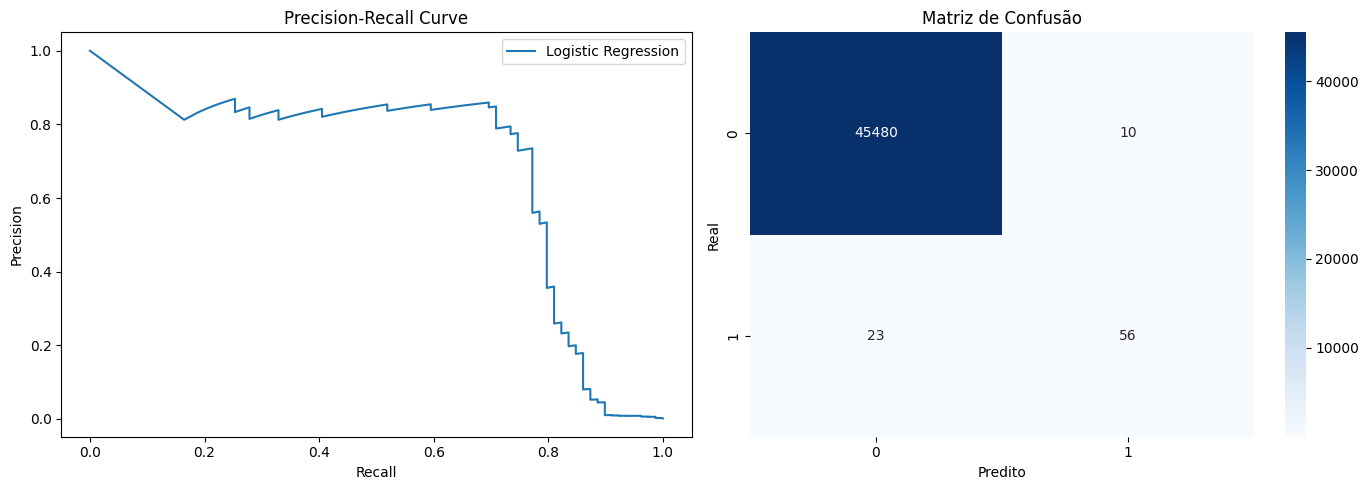

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls_lr, precisions_lr, label="Logistic Regression")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()


y_val_pred = (y_val_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues", 
            ax=axes[1])

axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusão")

plt.tight_layout()
plt.show()

# Geração do arquivo de submissão do modelo Logist Regression

In [ ]:
test_probs = model_LR.predict_proba(X_teste_final)[:,1] 
 
submission = pd.DataFrame({
    "id": dados_teste["id"],
    "Class": test_probs  
})

print(" Prévia da submissão:")
print(submission.head())

submission.to_csv("submission_logistregression.csv", index=False)

 Prévia da submissão:
       id     Class
0  263021  0.013781
1   11379  0.033789
2  147284  0.002001
3  219440  0.005738
4   36940  0.970236


In [ ]:
print(submission.shape) # checagem
print(dados_teste.shape)
print(submission.isna().sum())


(56962, 2)
(56962, 31)
id       0
Class    0
dtype: int64


# Treinamento dos dados utilizando o Modelo :LightGBM

**é um algoritmo de boosting baseado em árvores de decisão, focado em alta performance e velocidade. Ele constrói várias árvores sequencialmente para corrigir erros das anteriores, funcionando muito bem em dados tabulares e grandes volumes, com bom equilíbrio entre precisão e eficiência.**

In [ ]:
model_Lg = lgb.LGBMClassifier(
    n_estimators=800, # número de árvores
    learning_rate=0.03, # taxa de aprendizado
    max_depth=-1, # profundidade máxima das árvores, -1 significa sem limite
    num_leaves=64, # número de folhas em cada árvore
    min_child_samples=20, # número mínimo de amostras em um nó folha
    subsample=0.8, # porcentagem de amostras a serem usadas para cada árvore
    colsample_bytree=0.8, # porcentagem de colunas a serem amostradas para cada árvore
    class_weight="balanced", # lida com desbalanceamento
    random_state=42 # para reprodutibilidade
)

model_Lg.fit( #treinamento do modelo
    X_train.values,
    y_train.values
)

[LightGBM] [Info] Number of positive: 315, number of negative: 181961
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032778 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,800
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Importâncias de cada feature para o treinamento

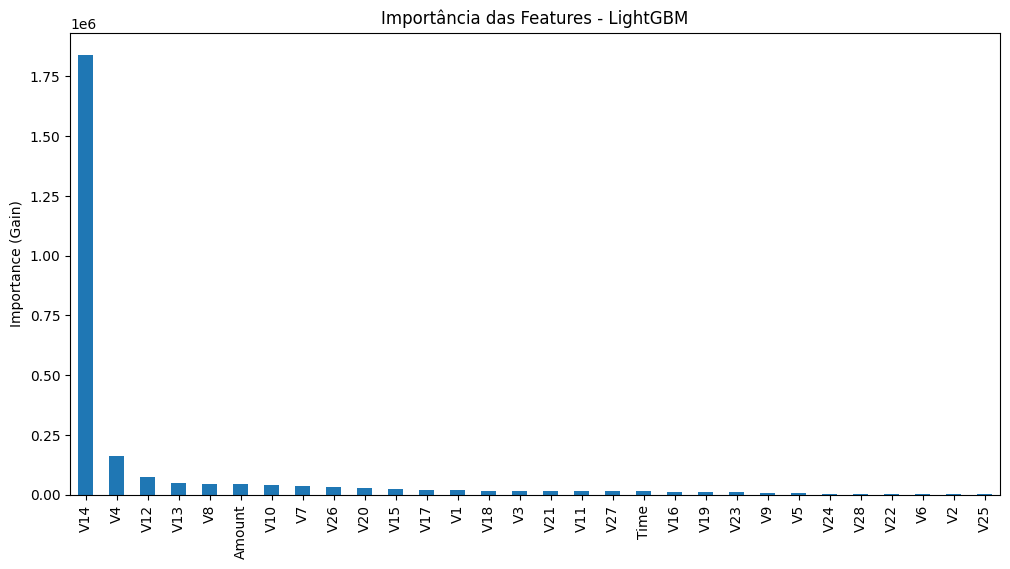

In [ ]:
features_usadas = dados_treino.drop(columns=["id", "Class"]).columns 

importancia = pd.Series(
    model_Lg.booster_.feature_importance(importance_type="gain"),
    index=features_usadas
).sort_values(ascending=False)

plt.figure(figsize=(12,6))
importancia.plot(kind="bar")
plt.title("Importância das Features - LightGBM")
plt.ylabel("Importance (Gain)")
plt.show()


In [29]:
# Probabilidade da classe positiva
y_val_proba = model_Lg.predict_proba(X_val)[:, 1] 
precisions_lg, recalls_lg, thresholds = precision_recall_curve(y_val, y_val_proba)
# Escolher threshold que maximiza F1
f1_scores = 2 * (precisions_lg * recalls_lg) / (precisions_lg + recalls_lg + 1e-8)  # Adicionando um pequeno valor para evitar divisão por zero
best_threshold = thresholds[f1_scores.argmax()]
print("Melhor threshold:", best_threshold)



Melhor threshold: 0.9597781958483743


In [30]:
# Fazendo as previsões no conjunto de teste
predictions = model_Lg.predict(X_teste_final)

print(f"Total de previsões: {len(predictions)}")
print(f"Previsões de fraude: {sum(predictions)}")
print(f"Previsões de transações normais: {len(predictions) - sum(predictions)}")


# Previsões discretas
y_val_pred = (y_val_proba >= best_threshold).astype(int)

print("Threshold usado:", best_threshold)

# ROC-AUC
roc_auc = roc_auc_score(y_val, y_val_proba)
print("ROC-AUC:", roc_auc)

# Accuracy
accuracy = accuracy_score(y_val, y_val_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_val, y_val_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_val, y_val_pred)
print("Recall:", recall)

# F1-score
f1 = f1_score(y_val, y_val_pred)
print("F1-score:", f1)

# Relatório completo
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))


Total de previsões: 56962
Previsões de fraude: 90
Previsões de transações normais: 56872
Threshold usado: 0.9597781958483743
ROC-AUC: 0.9639748338068458
Accuracy: 0.9995830498804011
Precision: 0.96875
Recall: 0.7848101265822784
F1-score: 0.8671328671328671

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45490
           1       0.97      0.78      0.87        79

    accuracy                           1.00     45569
   macro avg       0.98      0.89      0.93     45569
weighted avg       1.00      1.00      1.00     45569



# Matriz de Confusão Utilizando e Curva  Precision-recal a melhor trashhord

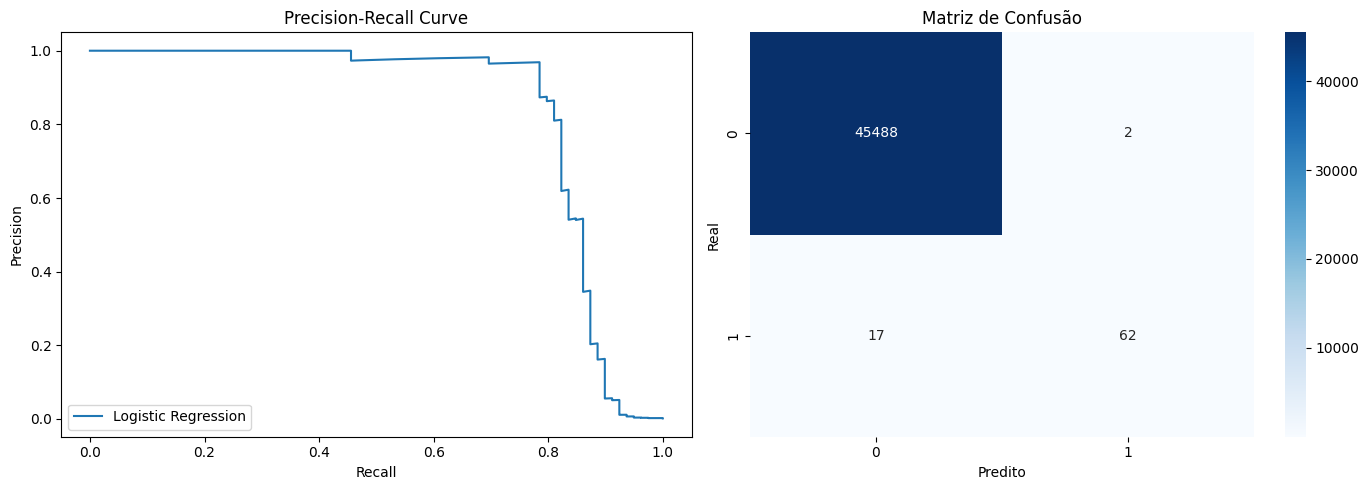

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls_lg, precisions_lg, label="Logistic Regression")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()


y_val_pred = (y_val_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues", 
            ax=axes[1])

axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusão")

plt.tight_layout()
plt.show()

# Geração do arquivo de submissão do modelo Light GBM

In [31]:
probs_test = model_Lg.predict_proba(X_teste_final)[:, 1]
#gerando a submissão para o LightGBM
submission = pd.DataFrame({
    "id": dados_teste["id"],
    "target": probs_test
})

print(" Prévia da submissão:")
print(submission.head())

submission.to_csv("submission_LightGBM.csv", index=False)


 Prévia da submissão:
       id        target
0  263021  4.178279e-09
1   11379  7.116605e-09
2  147284  2.119005e-07
3  219440  1.563773e-09
4   36940  7.053743e-08


# Comparação entre os dois modelos

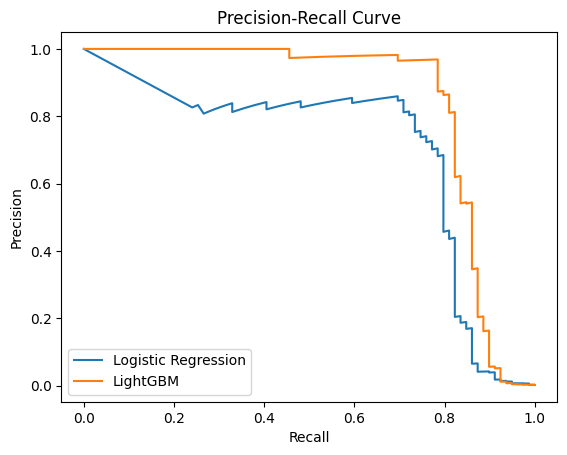

In [33]:
plt.plot(recalls_lr, precisions_lr, label="Logistic Regression") #curva de precisão-recall para a regressão logística
plt.plot(recalls_lg, precisions_lg, label="LightGBM") #curva de precisão-recall para o LightGBM

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()  
plt.show()
